In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import time

In [3]:
df = pd.read_csv("data/garments_worker_productivity.csv")

df.head()

,date,quarter,department,day,team,targeted_productivity,smv,wip,over_time,incentive,idle_time,idle_men,no_of_style_change,no_of_workers,actual_productivity
0,1/1/2015,Quarter1,sweing,Thursday,8,0.80,26.16,1108.0,7080,98,0.0,0,0,59.0,0.940725
1,1/1/2015,Quarter1,finishing,Thursday,1,0.75,3.94,NaN,960,0,0.0,0,0,8.0,0.886500
2,1/1/2015,Quarter1,sweing,Thursday,11,0.80,11.41,968.0,3660,50,0.0,0,0,30.5,0.800570
3,1/1/2015,Quarter1,sweing,Thursday,12,0.80,11.41,968.0,3660,50,0.0,0,0,30.5,0.800570
4,1/1/2015,Quarter1,sweing,Thursday,6,0.80,25.90,1170.0,1920,50,0.0,0,0,56.0,0.800382


In [4]:
df.shape

(1197, 15)

In [5]:
df.columns

Index(['date', 'quarter', 'department', 'day', 'team', 'targeted_productivity',
       'smv', 'wip', 'over_time', 'incentive', 'idle_time', 'idle_men',
       'no_of_style_change', 'no_of_workers', 'actual_productivity'],
      dtype='str')

In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1197 entries, 0 to 1196
Data columns (total 15 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   date                   1197 non-null   str    
 1   quarter                1197 non-null   str    
 2   department             1197 non-null   str    
 3   day                    1197 non-null   str    
 4   team                   1197 non-null   int64  
 5   targeted_productivity  1197 non-null   float64
 6   smv                    1197 non-null   float64
 7   wip                    691 non-null    float64
 8   over_time              1197 non-null   int64  
 9   incentive              1197 non-null   int64  
 10  idle_time              1197 non-null   float64
 11  idle_men               1197 non-null   int64  
 12  no_of_style_change     1197 non-null   int64  
 13  no_of_workers          1197 non-null   float64
 14  actual_productivity    1197 non-null   float64
dtypes: float64(6), 

In [7]:
df.isnull().sum()

date                       0
quarter                    0
department                 0
day                        0
team                       0
targeted_productivity      0
smv                        0
wip                      506
over_time                  0
incentive                  0
idle_time                  0
idle_men                   0
no_of_style_change         0
no_of_workers              0
actual_productivity        0
dtype: int64

In [8]:
(df.isnull().sum() / len(df) * 100).sort_values(ascending=False)

wip                      42.272348
date                      0.000000
quarter                   0.000000
department                0.000000
day                       0.000000
team                      0.000000
targeted_productivity     0.000000
smv                       0.000000
over_time                 0.000000
incentive                 0.000000
idle_time                 0.000000
idle_men                  0.000000
no_of_style_change        0.000000
no_of_workers             0.000000
actual_productivity       0.000000
dtype: float64

In [9]:
df["wip"].describe()

count      691.000000
mean      1190.465991
std       1837.455001
min          7.000000
25%        774.500000
50%       1039.000000
75%       1252.500000
max      23122.000000
Name: wip, dtype: float64

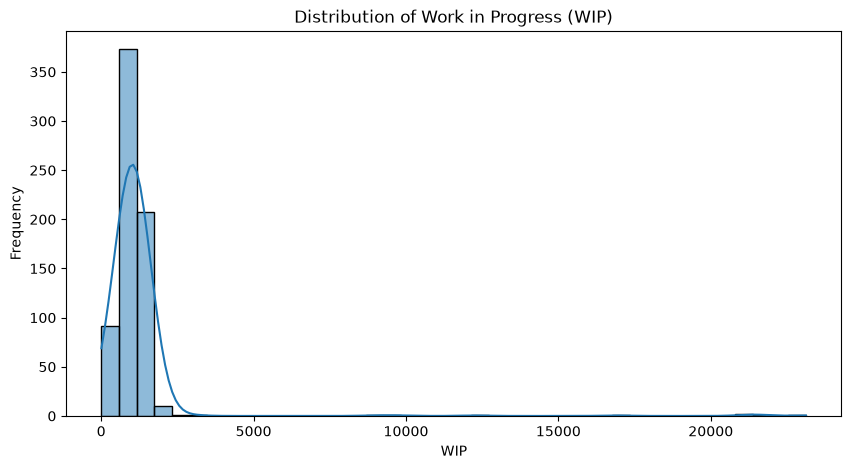

In [10]:
plt.figure(figsize=(10, 5))

sns.histplot(df["wip"].dropna(), bins=40, kde=True)

plt.title("Distribution of Work in Progress (WIP)")
plt.xlabel("WIP")
plt.ylabel("Frequency")
plt.show()

In [11]:
Q1 = df["wip"].quantile(0.25)
Q3 = df["wip"].quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = df[
    (df["wip"] < lower_bound) |
    (df["wip"] > upper_bound)
]["wip"].dropna()

print("Q1:", Q1)
print("Q3:", Q3)
print("IQR:", IQR)
print("Lower bound:", lower_bound)
print("Upper bound:", upper_bound)
print("Number of extreme values:", len(outliers))

Q1: 774.5
Q3: 1252.5
IQR: 478.0
Lower bound: 57.5
Upper bound: 1969.5
Number of extreme values: 22


In [12]:
outliers.sort_values().to_list()

[7.0,
 10.0,
 11.0,
 12.0,
 13.0,
 14.0,
 15.0,
 29.0,
 30.0,
 52.0,
 2103.0,
 2120.0,
 2698.0,
 2984.0,
 8992.0,
 9792.0,
 12261.0,
 16882.0,
 21266.0,
 21385.0,
 21540.0,
 23122.0]

In [13]:
wip_extreme_rows = df[
    (df["wip"] < lower_bound) |
    (df["wip"] > upper_bound)
].sort_values("wip")

wip_extreme_rows[
    [
        "date",
        "department",
        "team",
        "wip",
        "over_time",
        "incentive",
        "no_of_workers",
        "targeted_productivity",
        "actual_productivity"
    ]
]

,date,department,team,wip,over_time,incentive,no_of_workers,targeted_productivity,actual_productivity
798,2/16/2015,sweing,8,7.0,7080,27,59.0,0.70,0.621972
747,2/12/2015,sweing,10,10.0,6000,0,50.0,0.80,0.441392
728,2/11/2015,sweing,3,11.0,6840,0,57.0,0.80,0.536902
782,2/15/2015,sweing,2,12.0,6900,0,57.5,0.80,0.432123
703,2/10/2015,sweing,11,13.0,3240,34,54.0,0.80,0.750648
745,2/12/2015,sweing,9,14.0,6960,0,58.0,0.80,0.497885
938,2/25/2015,sweing,5,15.0,1200,49,59.0,0.80,0.598792
1031,3/3/2015,sweing,7,29.0,7080,50,59.0,0.80,0.800116
1065,3/4/2015,sweing,8,30.0,6840,0,57.0,0.80,0.433263
1067,3/4/2015,sweing,6,52.0,3960,0,33.0,0.75,0.332146


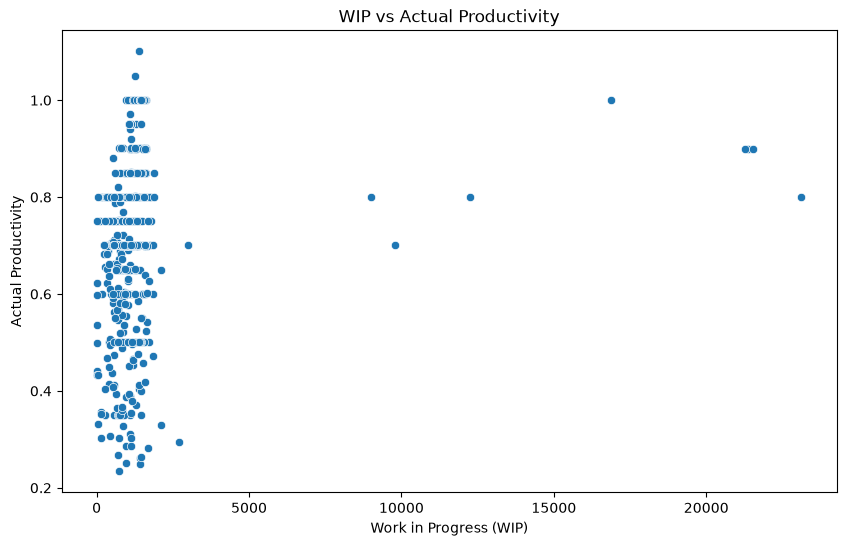

In [14]:
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=df,
    x="wip",
    y="actual_productivity"
)

plt.title("WIP vs Actual Productivity")
plt.xlabel("Work in Progress (WIP)")
plt.ylabel("Actual Productivity")
plt.show()

In [15]:
categorical_columns = ["quarter", "department", "day"]

for column in categorical_columns:
    print(f"\n{column}")
    print(df[column].unique())
    print("Number of unique values:", df[column].nunique())


quarter
<ArrowStringArray>
['Quarter1', 'Quarter2', 'Quarter3', 'Quarter4', 'Quarter5']
Length: 5, dtype: str
Number of unique values: 5

department
<ArrowStringArray>
['sweing', 'finishing ', 'finishing']
Length: 3, dtype: str
Number of unique values: 3

day
<ArrowStringArray>
['Thursday', 'Saturday', 'Sunday', 'Monday', 'Tuesday', 'Wednesday']
Length: 6, dtype: str
Number of unique values: 6


In [16]:
string_columns = df.select_dtypes(include="string").columns

for column in string_columns:
    df[column] = df[column].str.strip()

In [17]:
for column in categorical_columns:
    print(f"\n{column}")
    print(df[column].unique())
    print("Number of unique values:", df[column].nunique())


quarter
<ArrowStringArray>
['Quarter1', 'Quarter2', 'Quarter3', 'Quarter4', 'Quarter5']
Length: 5, dtype: str
Number of unique values: 5

department
<ArrowStringArray>
['sweing', 'finishing']
Length: 2, dtype: str
Number of unique values: 2

day
<ArrowStringArray>
['Thursday', 'Saturday', 'Sunday', 'Monday', 'Tuesday', 'Wednesday']
Length: 6, dtype: str
Number of unique values: 6


In [18]:
df["date"] = pd.to_datetime(df["date"], dayfirst=False)

print("Minimum date:", df["date"].min())
print("Maximum date:", df["date"].max())
print("Number of unique dates:", df["date"].nunique())

Minimum date: 2015-01-01 00:00:00
Maximum date: 2015-03-11 00:00:00
Number of unique dates: 59


In [19]:
df["date"].dt.month.value_counts().sort_index()

date
1    542
2    443
3    212
Name: count, dtype: int64

In [20]:
df["MeetsTarget"] = (
    df["actual_productivity"] >= df["targeted_productivity"]
).astype(int)

In [21]:
df["MeetsTarget"].value_counts()

MeetsTarget
1    875
0    322
Name: count, dtype: int64

In [22]:
class_distribution = pd.DataFrame({
    "Count": df["MeetsTarget"].value_counts().sort_index(),
    "Percentage": df["MeetsTarget"].value_counts(normalize=True).sort_index() * 100
})

class_distribution

,Count,Percentage
MeetsTarget,,
0,322,26.900585
1,875,73.099415


In [23]:
target_regression = "actual_productivity"
target_classification = "MeetsTarget"

features = [
    "quarter",
    "department",
    "day",
    "team",
    "targeted_productivity",
    "smv",
    "wip",
    "over_time",
    "incentive",
    "idle_time",
    "idle_men",
    "no_of_style_change",
    "no_of_workers"
]

X = df[features].copy()

y_regression = df[target_regression].copy()
y_classification = df[target_classification].copy()

In [24]:
print("Feature columns:")
print(X.columns.tolist())

print("\nNumber of features:", X.shape[1])

print("\nRegression target:", y_regression.name)
print("Classification target:", y_classification.name)

Feature columns:
['quarter', 'department', 'day', 'team', 'targeted_productivity', 'smv', 'wip', 'over_time', 'incentive', 'idle_time', 'idle_men', 'no_of_style_change', 'no_of_workers']

Number of features: 13

Regression target: actual_productivity
Classification target: MeetsTarget


Part A:

In [25]:
from sklearn.model_selection import train_test_split

train_indices, test_indices = train_test_split(
    np.arange(len(df)),
    test_size=0.20,
    random_state=42,
    stratify=y_classification
)

print("Training samples:", len(train_indices))
print("Testing samples:", len(test_indices))

Training samples: 957
Testing samples: 240


In [26]:
X_train = X.iloc[train_indices].copy()
X_test = X.iloc[test_indices].copy()

y_reg_train = y_regression.iloc[train_indices].copy()
y_reg_test = y_regression.iloc[test_indices].copy()

y_cls_train = y_classification.iloc[train_indices].copy()
y_cls_test = y_classification.iloc[test_indices].copy()

In [27]:
print("X_train:", X_train.shape)
print("X_test :", X_test.shape)

print("\nRegression:")
print("y_reg_train:", y_reg_train.shape)
print("y_reg_test :", y_reg_test.shape)

print("\nClassification:")
print("y_cls_train:", y_cls_train.shape)
print("y_cls_test :", y_cls_test.shape)

X_train: (957, 13)
X_test : (240, 13)

Regression:
y_reg_train: (957,)
y_reg_test : (240,)

Classification:
y_cls_train: (957,)
y_cls_test : (240,)


In [28]:
print("Overall:")
print(y_classification.value_counts(normalize=True).sort_index())

print("\nTraining:")
print(y_cls_train.value_counts(normalize=True).sort_index())

print("\nTesting:")
print(y_cls_test.value_counts(normalize=True).sort_index())

Overall:
MeetsTarget
0    0.269006
1    0.730994
Name: proportion, dtype: float64

Training:
MeetsTarget
0    0.268548
1    0.731452
Name: proportion, dtype: float64

Testing:
MeetsTarget
0    0.270833
1    0.729167
Name: proportion, dtype: float64


In [29]:
categorical_features = [
    "quarter",
    "department",
    "day"
]

numerical_features = [
    "team",
    "targeted_productivity",
    "smv",
    "wip",
    "over_time",
    "incentive",
    "idle_time",
    "idle_men",
    "no_of_style_change",
    "no_of_workers"
]

print("Categorical features:", categorical_features)
print("Numerical features:", numerical_features)

Categorical features: ['quarter', 'department', 'day']
Numerical features: ['team', 'targeted_productivity', 'smv', 'wip', 'over_time', 'incentive', 'idle_time', 'idle_men', 'no_of_style_change', 'no_of_workers']


In [30]:
X_train.isnull().sum()

quarter                    0
department                 0
day                        0
team                       0
targeted_productivity      0
smv                        0
wip                      401
over_time                  0
incentive                  0
idle_time                  0
idle_men                   0
no_of_style_change         0
no_of_workers              0
dtype: int64

In [31]:
X_test.isnull().sum()

quarter                    0
department                 0
day                        0
team                       0
targeted_productivity      0
smv                        0
wip                      105
over_time                  0
incentive                  0
idle_time                  0
idle_men                   0
no_of_style_change         0
no_of_workers              0
dtype: int64

In [32]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

In [33]:
numerical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

In [34]:
categorical_pipeline = Pipeline([
    ("encoder", OneHotEncoder(handle_unknown="ignore", sparse_output=False))
])

In [35]:
preprocessor = ColumnTransformer([
    ("numerical", numerical_pipeline, numerical_features),
    ("categorical", categorical_pipeline, categorical_features)
])

In [36]:
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

In [37]:
print("Original training shape:", X_train.shape)
print("Processed training shape:", X_train_processed.shape)

print("\nOriginal test shape:", X_test.shape)
print("Processed test shape:", X_test_processed.shape)

Original training shape: (957, 13)
Processed training shape: (957, 23)

Original test shape: (240, 13)
Processed test shape: (240, 23)


In [38]:
print("Missing values in processed training data:",
      np.isnan(X_train_processed).sum())

print("Missing values in processed test data:",
      np.isnan(X_test_processed).sum())

Missing values in processed training data: 0
Missing values in processed test data: 0


In [39]:
feature_names = preprocessor.get_feature_names_out()

print("Number of processed features:", len(feature_names))
print("\nProcessed feature names:")
for i, feature in enumerate(feature_names):
    print(i, feature)

Number of processed features: 23

Processed feature names:
0 numerical__team
1 numerical__targeted_productivity
2 numerical__smv
3 numerical__wip
4 numerical__over_time
5 numerical__incentive
6 numerical__idle_time
7 numerical__idle_men
8 numerical__no_of_style_change
9 numerical__no_of_workers
10 categorical__quarter_Quarter1
11 categorical__quarter_Quarter2
12 categorical__quarter_Quarter3
13 categorical__quarter_Quarter4
14 categorical__quarter_Quarter5
15 categorical__department_finishing
16 categorical__department_sweing
17 categorical__day_Monday
18 categorical__day_Saturday
19 categorical__day_Sunday
20 categorical__day_Thursday
21 categorical__day_Tuesday
22 categorical__day_Wednesday


In [40]:
from sklearn.linear_model import LinearRegression

In [41]:
linear_model = LinearRegression()

start_time = time.perf_counter()

linear_model.fit(X_train_processed, y_reg_train)

linear_training_time = time.perf_counter() - start_time

print("Linear Regression training time:", linear_training_time, "seconds")

Linear Regression training time: 0.004870208999989245 seconds


In [42]:
start_time = time.perf_counter()

y_reg_pred = linear_model.predict(X_test_processed)

linear_prediction_time = time.perf_counter() - start_time

print("Linear Regression prediction time:", linear_prediction_time, "seconds")

Linear Regression prediction time: 0.00013191700003289952 seconds


In [43]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

mae = mean_absolute_error(y_reg_test, y_reg_pred)
rmse = np.sqrt(mean_squared_error(y_reg_test, y_reg_pred))
r2 = r2_score(y_reg_test, y_reg_pred)

print("Linear Regression Results")
print("-------------------------")
print("MAE :", mae)
print("RMSE:", rmse)
print("R²  :", r2)

Linear Regression Results
-------------------------
MAE : 0.10850276488125467
RMSE: 0.14575409595200192
R²  : 0.2684461883259476


In [44]:
from sklearn.linear_model import LogisticRegression

In [45]:
logistic_model = LogisticRegression(max_iter=1000)

start_time = time.perf_counter()

logistic_model.fit(X_train_processed, y_cls_train)

logistic_training_time = time.perf_counter() - start_time

print("Logistic Regression training time:", logistic_training_time, "seconds")

Logistic Regression training time: 0.01507062500002121 seconds


In [46]:
start_time = time.perf_counter()

y_cls_pred = logistic_model.predict(X_test_processed)

logistic_prediction_time = time.perf_counter() - start_time

print("Logistic Regression prediction time:", logistic_prediction_time, "seconds")

Logistic Regression prediction time: 0.0004635000000234868 seconds


In [47]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

accuracy = accuracy_score(y_cls_test, y_cls_pred)
precision = precision_score(y_cls_test, y_cls_pred)
recall = recall_score(y_cls_test, y_cls_pred)
f1 = f1_score(y_cls_test, y_cls_pred)

print("Logistic Regression Results")
print("---------------------------")
print("Accuracy :", accuracy)
print("Precision:", precision)
print("Recall   :", recall)
print("F1 Score :", f1)

Logistic Regression Results
---------------------------
Accuracy : 0.7083333333333334
Precision: 0.7536231884057971
Recall   : 0.8914285714285715
F1 Score : 0.8167539267015707


In [48]:
part_a_results = pd.DataFrame({
    "Model": ["Linear Regression", "Logistic Regression"],
    "Training Time (s)": [
        linear_training_time,
        logistic_training_time
    ],
    "Prediction Time (s)": [
        linear_prediction_time,
        logistic_prediction_time
    ],
    "Primary Metric 1": [mae, accuracy],
    "Primary Metric 2": [rmse, precision],
    "Primary Metric 3": [r2, recall],
    "Primary Metric 4": [np.nan, f1]
})

part_a_results

,Model,Training Time (s),Prediction Time (s),Primary Metric 1,Primary Metric 2,Primary Metric 3,Primary Metric 4
0,Linear Regression,0.004870,0.000132,0.108503,0.145754,0.268446,NaN
1,Logistic Regression,0.015071,0.000464,0.708333,0.753623,0.891429,0.816754


Part B

In [49]:
X_train_manual = X_train.copy()
X_test_manual = X_test.copy()

print("Manual training data shape:", X_train_manual.shape)
print("Manual test data shape:", X_test_manual.shape)

Manual training data shape: (957, 13)
Manual test data shape: (240, 13)


In [50]:
wip_median = X_train_manual["wip"].median()

print("Training WIP median:", wip_median)

Training WIP median: 1038.0


In [51]:
X_train_manual["wip"] = X_train_manual["wip"].fillna(wip_median)
X_test_manual["wip"] = X_test_manual["wip"].fillna(wip_median)

print("Missing WIP in training:", X_train_manual["wip"].isna().sum())
print("Missing WIP in testing :", X_test_manual["wip"].isna().sum())

Missing WIP in training: 0
Missing WIP in testing : 0


In [52]:
category_levels = {}

for column in categorical_features:
    category_levels[column] = sorted(X_train_manual[column].unique())
    
    print(f"{column}:")
    print(category_levels[column])

quarter:
['Quarter1', 'Quarter2', 'Quarter3', 'Quarter4', 'Quarter5']
department:
['finishing', 'sweing']
day:
['Monday', 'Saturday', 'Sunday', 'Thursday', 'Tuesday', 'Wednesday']


In [53]:
def manual_one_hot_encode(data, category_levels):
    encoded = data.copy()

    for column, categories in category_levels.items():
        for category in categories:
            encoded[f"{column}_{category}"] = (
                encoded[column] == category
            ).astype(int)

        encoded = encoded.drop(columns=[column])

    return encoded


X_train_manual = manual_one_hot_encode(
    X_train_manual,
    category_levels
)

X_test_manual = manual_one_hot_encode(
    X_test_manual,
    category_levels
)

print("Manual training shape:", X_train_manual.shape)
print("Manual testing shape :", X_test_manual.shape)

Manual training shape: (957, 23)
Manual testing shape : (240, 23)


In [54]:
manual_numerical_columns = numerical_features

print("Numerical columns to scale:")
print(manual_numerical_columns)

Numerical columns to scale:
['team', 'targeted_productivity', 'smv', 'wip', 'over_time', 'incentive', 'idle_time', 'idle_men', 'no_of_style_change', 'no_of_workers']


In [55]:
training_means = X_train_manual[manual_numerical_columns].mean()
training_stds = X_train_manual[manual_numerical_columns].std(ddof=0)

print("Training means:")
print(training_means)

print("\nTraining standard deviations:")
print(training_stds)

Training means:
team                        6.452456
targeted_productivity       0.725726
smv                        15.140073
wip                      1110.163009
over_time                4595.287356
incentive                  35.933124
idle_time                   0.900731
idle_men                    0.393939
no_of_style_change          0.151515
no_of_workers              34.675549
dtype: float64

Training standard deviations:
team                        3.477812
targeted_productivity       0.101045
smv                        10.946214
wip                      1220.191086
over_time                3333.441680
incentive                 128.333396
idle_time                  14.201585
idle_men                    3.431748
no_of_style_change          0.427662
no_of_workers              22.206121
dtype: float64


In [56]:
X_train_manual[manual_numerical_columns] = (
    X_train_manual[manual_numerical_columns] - training_means
) / training_stds

X_test_manual[manual_numerical_columns] = (
    X_test_manual[manual_numerical_columns] - training_means
) / training_stds

print("Training numerical means after scaling:")
print(X_train_manual[manual_numerical_columns].mean().round(6))

print("\nTraining numerical standard deviations after scaling:")
print(X_train_manual[manual_numerical_columns].std(ddof=0).round(6))

Training numerical means after scaling:
team                     0.0
targeted_productivity    0.0
smv                      0.0
wip                     -0.0
over_time                0.0
incentive               -0.0
idle_time                0.0
idle_men                 0.0
no_of_style_change      -0.0
no_of_workers           -0.0
dtype: float64

Training numerical standard deviations after scaling:
team                     1.0
targeted_productivity    1.0
smv                      1.0
wip                      1.0
over_time                1.0
incentive                1.0
idle_time                1.0
idle_men                 1.0
no_of_style_change       1.0
no_of_workers            1.0
dtype: float64


In [57]:
print("Training shape:", X_train_manual.shape)
print("Testing shape :", X_test_manual.shape)

print("\nMissing values in training:",
      X_train_manual.isna().sum().sum())

print("Missing values in testing :",
      X_test_manual.isna().sum().sum())

print("\nNon-numeric columns in training:",
      X_train_manual.select_dtypes(exclude=np.number).columns.tolist())

print("Non-numeric columns in testing :",
      X_test_manual.select_dtypes(exclude=np.number).columns.tolist())

Training shape: (957, 23)
Testing shape : (240, 23)

Missing values in training: 0
Missing values in testing : 0

Non-numeric columns in training: []
Non-numeric columns in testing : []


In [58]:
X_train_lr = X_train_manual.to_numpy(dtype=float)
X_test_lr = X_test_manual.to_numpy(dtype=float)

X_train_lr = np.column_stack([
    np.ones(X_train_lr.shape[0]),
    X_train_lr
])

X_test_lr = np.column_stack([
    np.ones(X_test_lr.shape[0]),
    X_test_lr
])

y_train_lr = y_reg_train.to_numpy(dtype=float)
y_test_lr = y_reg_test.to_numpy(dtype=float)

print("Training matrix shape:", X_train_lr.shape)
print("Testing matrix shape :", X_test_lr.shape)

Training matrix shape: (957, 24)
Testing matrix shape : (240, 24)


In [59]:
start_time = time.perf_counter()

beta = np.linalg.pinv(X_train_lr) @ y_train_lr

manual_linear_training_time = time.perf_counter() - start_time

print("Manual Linear Regression training time:",
      manual_linear_training_time,
      "seconds")

print("\nNumber of learned coefficients:", len(beta))

Manual Linear Regression training time: 0.008102833000066312 seconds

Number of learned coefficients: 24


In [60]:
start_time = time.perf_counter()

y_reg_pred_manual = X_test_lr @ beta

manual_linear_prediction_time = time.perf_counter() - start_time

print("Manual Linear Regression prediction time:",
      manual_linear_prediction_time,
      "seconds")

print("\nNumber of predictions:", len(y_reg_pred_manual))

Manual Linear Regression prediction time: 0.00015512499976466643 seconds

Number of predictions: 240


In [61]:
errors = y_test_lr - y_reg_pred_manual

manual_mae = np.mean(np.abs(errors))

manual_rmse = np.sqrt(np.mean(errors ** 2))

ss_res = np.sum(errors ** 2)
ss_tot = np.sum((y_test_lr - np.mean(y_test_lr)) ** 2)

manual_r2 = 1 - (ss_res / ss_tot)

print("Manual MAE :", manual_mae)
print("Manual RMSE:", manual_rmse)
print("Manual R²  :", manual_r2)

Manual MAE : 0.10850276488125467
Manual RMSE: 0.14575409595200195
Manual R²  : 0.26844618832594735


In [62]:
manual_linear_results = {
    "Model": "Manual Linear Regression",
    "Training Time (s)": manual_linear_training_time,
    "Prediction Time (s)": manual_linear_prediction_time,
    "MAE": manual_mae,
    "RMSE": manual_rmse,
    "R²": manual_r2
}

manual_linear_results

{'Model': 'Manual Linear Regression',
 'Training Time (s)': 0.008102833000066312,
 'Prediction Time (s)': 0.00015512499976466643,
 'MAE': np.float64(0.10850276488125467),
 'RMSE': np.float64(0.14575409595200195),
 'R²': np.float64(0.26844618832594735)}

In [63]:
X_train_log = X_train_manual.to_numpy(dtype=float)
X_test_log = X_test_manual.to_numpy(dtype=float)

X_train_log = np.column_stack([
    np.ones(X_train_log.shape[0]),
    X_train_log
])

X_test_log = np.column_stack([
    np.ones(X_test_log.shape[0]),
    X_test_log
])

y_train_log = y_cls_train.to_numpy(dtype=float)
y_test_log = y_cls_test.to_numpy(dtype=float)

print("Training matrix shape:", X_train_log.shape)
print("Testing matrix shape :", X_test_log.shape)
print("Training target shape:", y_train_log.shape)
print("Testing target shape :", y_test_log.shape)

Training matrix shape: (957, 24)
Testing matrix shape : (240, 24)
Training target shape: (957,)
Testing target shape : (240,)


In [64]:
def sigmoid(z):
    return 1 / (1 + np.exp(-z))

In [65]:
test_values = np.array([-10, -2, 0, 2, 10])

print(sigmoid(test_values))

[4.53978687e-05 1.19202922e-01 5.00000000e-01 8.80797078e-01
 9.99954602e-01]


In [66]:
n_features = X_train_log.shape[1]

beta_log = np.zeros(n_features)

learning_rate = 0.01
iterations = 10000

print("Number of coefficients:", len(beta_log))
print("Learning rate:", learning_rate)
print("Iterations:", iterations)

Number of coefficients: 24
Learning rate: 0.01
Iterations: 10000


In [67]:
start_time = time.perf_counter()

for _ in range(iterations):

    # Step 1: Linear combination
    z = X_train_log @ beta_log

    # Step 2: Convert linear output into probabilities
    probabilities = sigmoid(z)

    # Step 3: Calculate gradient
    gradient = (
        X_train_log.T @ (probabilities - y_train_log)
    ) / len(y_train_log)

    # Step 4: Update coefficients
    beta_log = beta_log - learning_rate * gradient

manual_logistic_training_time = time.perf_counter() - start_time

print("Manual Logistic Regression training time:",
      manual_logistic_training_time,
      "seconds")

print("Number of learned coefficients:", len(beta_log))

Manual Logistic Regression training time: 0.0923192499999459 seconds
Number of learned coefficients: 24


In [68]:
start_time = time.perf_counter()

z_test_log = X_test_log @ beta_log

y_cls_prob_manual = sigmoid(z_test_log)

manual_logistic_prediction_time = time.perf_counter() - start_time

print("Manual Logistic Regression prediction time:",
      manual_logistic_prediction_time,
      "seconds")

print("\nNumber of probabilities:", len(y_cls_prob_manual))
print("First 10 probabilities:")
print(y_cls_prob_manual[:10])

Manual Logistic Regression prediction time: 0.00020433400004549185 seconds

Number of probabilities: 240
First 10 probabilities:
[0.70301995 0.79739105 0.82011677 0.38567518 0.90551007 0.8501124
 0.58012207 0.63027074 0.58021427 0.54740641]


In [69]:
y_cls_pred_manual = (y_cls_prob_manual >= 0.5).astype(int)

print("First 20 predicted classes:")
print(y_cls_pred_manual[:20])

print("\nClass distribution:")
print(pd.Series(y_cls_pred_manual).value_counts().sort_index())

First 20 predicted classes:
[1 1 1 0 1 1 1 1 1 1 0 1 1 1 1 1 1 1 1 1]

Class distribution:
0     28
1    212
Name: count, dtype: int64


In [70]:
tp = np.sum((y_test_log == 1) & (y_cls_pred_manual == 1))
tn = np.sum((y_test_log == 0) & (y_cls_pred_manual == 0))
fp = np.sum((y_test_log == 0) & (y_cls_pred_manual == 1))
fn = np.sum((y_test_log == 1) & (y_cls_pred_manual == 0))

manual_accuracy = (tp + tn) / len(y_test_log)

manual_precision = tp / (tp + fp) if (tp + fp) > 0 else 0

manual_recall = tp / (tp + fn) if (tp + fn) > 0 else 0

manual_f1 = (
    2 * manual_precision * manual_recall /
    (manual_precision + manual_recall)
    if (manual_precision + manual_recall) > 0
    else 0
)

print("True Positives :", tp)
print("True Negatives :", tn)
print("False Positives:", fp)
print("False Negatives:", fn)

print("\nManual Accuracy :", manual_accuracy)
print("Manual Precision:", manual_precision)
print("Manual Recall   :", manual_recall)
print("Manual F1       :", manual_f1)

True Positives : 159
True Negatives : 12
False Positives: 53
False Negatives: 16

Manual Accuracy : 0.7125
Manual Precision: 0.75
Manual Recall   : 0.9085714285714286
Manual F1       : 0.8217054263565893


In [71]:
manual_logistic_results = {
    "Model": "Manual Logistic Regression",
    "Training Time (s)": manual_logistic_training_time,
    "Prediction Time (s)": manual_logistic_prediction_time,
    "Accuracy": manual_accuracy,
    "Precision": manual_precision,
    "Recall": manual_recall,
    "F1": manual_f1
}

manual_logistic_results

{'Model': 'Manual Logistic Regression',
 'Training Time (s)': 0.0923192499999459,
 'Prediction Time (s)': 0.00020433400004549185,
 'Accuracy': np.float64(0.7125),
 'Precision': np.float64(0.75),
 'Recall': np.float64(0.9085714285714286),
 'F1': np.float64(0.8217054263565893)}

Part C

In [72]:
comparison_results = pd.DataFrame([
    {
        "Implementation": "Scikit-learn",
        "Model": "Linear Regression",
        "Training Time (s)": linear_training_time,
        "Prediction Time (s)": linear_prediction_time,
        "MAE": mae,
        "RMSE": rmse,
        "R²": r2
    },
    {
        "Implementation": "Manual NumPy",
        "Model": "Linear Regression",
        "Training Time (s)": manual_linear_training_time,
        "Prediction Time (s)": manual_linear_prediction_time,
        "MAE": manual_mae,
        "RMSE": manual_rmse,
        "R²": manual_r2
    },
    {
        "Implementation": "Scikit-learn",
        "Model": "Logistic Regression",
        "Training Time (s)": logistic_training_time,
        "Prediction Time (s)": logistic_prediction_time,
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1": f1
    },
    {
        "Implementation": "Manual NumPy",
        "Model": "Logistic Regression",
        "Training Time (s)": manual_logistic_training_time,
        "Prediction Time (s)": manual_logistic_prediction_time,
        "Accuracy": manual_accuracy,
        "Precision": manual_precision,
        "Recall": manual_recall,
        "F1": manual_f1
    }
])

comparison_results

,Implementation,Model,Training Time (s),Prediction Time (s),MAE,RMSE,R²,Accuracy,Precision,Recall,F1
0,Scikit-learn,Linear Regression,0.004870,0.000132,0.108503,0.145754,0.268446,NaN,NaN,NaN,NaN
1,Manual NumPy,Linear Regression,0.008103,0.000155,0.108503,0.145754,0.268446,NaN,NaN,NaN,NaN
2,Scikit-learn,Logistic Regression,0.015071,0.000464,NaN,NaN,NaN,0.708333,0.753623,0.891429,0.816754
3,Manual NumPy,Logistic Regression,0.092319,0.000204,NaN,NaN,NaN,0.712500,0.750000,0.908571,0.821705


In [73]:
beta_log_loss = np.zeros(X_train_log.shape[1])

learning_rate_loss = 0.01
iterations_loss = 10000

loss_history = []

start_time = time.perf_counter()

for iteration in range(iterations_loss):

    z = X_train_log @ beta_log_loss

    probabilities = sigmoid(z)

    # Avoid log(0)
    probabilities_clipped = np.clip(
        probabilities,
        1e-15,
        1 - 1e-15
    )

    loss = -np.mean(
        y_train_log * np.log(probabilities_clipped)
        +
        (1 - y_train_log) * np.log(1 - probabilities_clipped)
    )

    gradient = (
        X_train_log.T @ (probabilities - y_train_log)
    ) / len(y_train_log)

    beta_log_loss = beta_log_loss - learning_rate_loss * gradient

    if iteration % 100 == 0:
        loss_history.append(loss)

optimized_tracking_time = time.perf_counter() - start_time

print("Training time:", optimized_tracking_time, "seconds")
print("Initial loss:", loss_history[0])
print("Final loss:", loss_history[-1])

Training time: 0.19425441700013835 seconds
Initial loss: 0.6931471805599452
Final loss: 0.48534555266726787


In [74]:
loss_check = pd.DataFrame({
    "Iteration": np.arange(0, iterations_loss, 100),
    "Log Loss": loss_history
})

print(loss_check.iloc[::10])

    Iteration  Log Loss
0           0  0.693147
10       1000  0.518505
20       2000  0.507527
30       3000  0.500692
40       4000  0.496003
50       5000  0.492675
60       6000  0.490255
70       7000  0.488460
80       8000  0.487108
90       9000  0.486074


In [75]:
beta_log_optimized = np.zeros(X_train_log.shape[1])

optimized_learning_rate = 0.01
optimized_iterations = 5000

start_time = time.perf_counter()

for _ in range(optimized_iterations):

    z = X_train_log @ beta_log_optimized

    probabilities = sigmoid(z)

    gradient = (
        X_train_log.T @ (probabilities - y_train_log)
    ) / len(y_train_log)

    beta_log_optimized = (
        beta_log_optimized
        - optimized_learning_rate * gradient
    )

optimized_logistic_training_time = (
    time.perf_counter() - start_time
)

print(
    "Optimized training time:",
    optimized_logistic_training_time,
    "seconds"
)

Optimized training time: 0.05330600000024788 seconds


In [76]:
start_time = time.perf_counter()

z_test_optimized = X_test_log @ beta_log_optimized

probabilities_optimized = sigmoid(z_test_optimized)

y_pred_optimized = (
    probabilities_optimized >= 0.5
).astype(int)

optimized_logistic_prediction_time = (
    time.perf_counter() - start_time
)

tp_opt = np.sum(
    (y_test_log == 1) & (y_pred_optimized == 1)
)
tn_opt = np.sum(
    (y_test_log == 0) & (y_pred_optimized == 0)
)
fp_opt = np.sum(
    (y_test_log == 0) & (y_pred_optimized == 1)
)
fn_opt = np.sum(
    (y_test_log == 1) & (y_pred_optimized == 0)
)

optimized_accuracy = (
    (tp_opt + tn_opt) / len(y_test_log)
)

optimized_precision = (
    tp_opt / (tp_opt + fp_opt)
    if (tp_opt + fp_opt) > 0 else 0
)

optimized_recall = (
    tp_opt / (tp_opt + fn_opt)
    if (tp_opt + fn_opt) > 0 else 0
)

optimized_f1 = (
    2 * optimized_precision * optimized_recall /
    (optimized_precision + optimized_recall)
    if (optimized_precision + optimized_recall) > 0
    else 0
)

print("Optimized prediction time:",
      optimized_logistic_prediction_time,
      "seconds")

print("\nAccuracy :", optimized_accuracy)
print("Precision:", optimized_precision)
print("Recall   :", optimized_recall)
print("F1       :", optimized_f1)

print("\nConfusion Matrix Counts")
print("TP:", tp_opt)
print("TN:", tn_opt)
print("FP:", fp_opt)
print("FN:", fn_opt)

Optimized prediction time: 0.0001687499998297426 seconds

Accuracy : 0.7125
Precision: 0.7431192660550459
Recall   : 0.9257142857142857
F1       : 0.8244274809160306

Confusion Matrix Counts
TP: 162
TN: 9
FP: 56
FN: 13


In [77]:
beta_log_early = np.zeros(X_train_log.shape[1])

learning_rate_early = 0.01
max_iterations = 10000
tolerance = 1e-7
patience = 20

previous_loss = np.inf
stable_iterations = 0

start_time = time.perf_counter()

for iteration in range(max_iterations):

    z = X_train_log @ beta_log_early

    probabilities = sigmoid(z)

    probabilities_clipped = np.clip(
        probabilities,
        1e-15,
        1 - 1e-15
    )

    loss = -np.mean(
        y_train_log * np.log(probabilities_clipped)
        +
        (1 - y_train_log)
        * np.log(1 - probabilities_clipped)
    )

    gradient = (
        X_train_log.T @ (probabilities - y_train_log)
    ) / len(y_train_log)

    beta_log_early = (
        beta_log_early
        - learning_rate_early * gradient
    )

    loss_change = abs(previous_loss - loss)

    if loss_change < tolerance:
        stable_iterations += 1
    else:
        stable_iterations = 0

    if stable_iterations >= patience:
        break

    previous_loss = loss

early_stopping_training_time = (
    time.perf_counter() - start_time
)

print("Iterations actually performed:", iteration + 1)
print("Final loss:", loss)
print("Training time:",
      early_stopping_training_time,
      "seconds")

Iterations actually performed: 10000
Final loss: 0.48527499444920347
Training time: 0.1930229579998013 seconds


In [78]:
beta_log_lr = np.zeros(X_train_log.shape[1])

learning_rate_lr = 0.05
iterations_lr = 5000

start_time = time.perf_counter()

for _ in range(iterations_lr):

    z = X_train_log @ beta_log_lr

    probabilities = sigmoid(z)

    gradient = (
        X_train_log.T @ (probabilities - y_train_log)
    ) / len(y_train_log)

    beta_log_lr = (
        beta_log_lr
        - learning_rate_lr * gradient
    )

higher_lr_training_time = (
    time.perf_counter() - start_time
)

print("Training time:",
      higher_lr_training_time,
      "seconds")

Training time: 0.05285787499997241 seconds


In [79]:
start_time = time.perf_counter()

z_test_lr = X_test_log @ beta_log_lr

probabilities_lr = sigmoid(z_test_lr)

y_pred_lr = (
    probabilities_lr >= 0.5
).astype(int)

higher_lr_prediction_time = (
    time.perf_counter() - start_time
)

tp_lr = np.sum(
    (y_test_log == 1) & (y_pred_lr == 1)
)
tn_lr = np.sum(
    (y_test_log == 0) & (y_pred_lr == 0)
)
fp_lr = np.sum(
    (y_test_log == 0) & (y_pred_lr == 1)
)
fn_lr = np.sum(
    (y_test_log == 1) & (y_pred_lr == 0)
)

higher_lr_accuracy = (
    (tp_lr + tn_lr) / len(y_test_log)
)

higher_lr_precision = (
    tp_lr / (tp_lr + fp_lr)
    if (tp_lr + fp_lr) > 0 else 0
)

higher_lr_recall = (
    tp_lr / (tp_lr + fn_lr)
    if (tp_lr + fn_lr) > 0 else 0
)

higher_lr_f1 = (
    2 * higher_lr_precision * higher_lr_recall /
    (higher_lr_precision + higher_lr_recall)
    if (higher_lr_precision + higher_lr_recall) > 0
    else 0
)

print("Prediction time:",
      higher_lr_prediction_time,
      "seconds")

print("\nAccuracy :", higher_lr_accuracy)
print("Precision:", higher_lr_precision)
print("Recall   :", higher_lr_recall)
print("F1       :", higher_lr_f1)

print("\nTP:", tp_lr)
print("TN:", tn_lr)
print("FP:", fp_lr)
print("FN:", fn_lr)

Prediction time: 0.0001789580001059221 seconds

Accuracy : 0.7125
Precision: 0.7548076923076923
Recall   : 0.8971428571428571
F1       : 0.8198433420365535

TP: 157
TN: 14
FP: 51
FN: 18


In [80]:
beta_log_1000 = np.zeros(X_train_log.shape[1])

learning_rate_1000 = 0.01
iterations_1000 = 1000

start_time = time.perf_counter()

for _ in range(iterations_1000):

    z = X_train_log @ beta_log_1000

    probabilities = sigmoid(z)

    gradient = (
        X_train_log.T @ (probabilities - y_train_log)
    ) / len(y_train_log)

    beta_log_1000 = (
        beta_log_1000
        - learning_rate_1000 * gradient
    )

logistic_1000_training_time = (
    time.perf_counter() - start_time
)

print("Training time:",
      logistic_1000_training_time,
      "seconds")

Training time: 0.018093000000135362 seconds


In [81]:
start_time = time.perf_counter()

z_test_1000 = X_test_log @ beta_log_1000

probabilities_1000 = sigmoid(z_test_1000)

y_pred_1000 = (
    probabilities_1000 >= 0.5
).astype(int)

logistic_1000_prediction_time = (
    time.perf_counter() - start_time
)

tp_1000 = np.sum(
    (y_test_log == 1) & (y_pred_1000 == 1)
)
tn_1000 = np.sum(
    (y_test_log == 0) & (y_pred_1000 == 0)
)
fp_1000 = np.sum(
    (y_test_log == 0) & (y_pred_1000 == 1)
)
fn_1000 = np.sum(
    (y_test_log == 1) & (y_pred_1000 == 0)
)

accuracy_1000 = (
    (tp_1000 + tn_1000) / len(y_test_log)
)

precision_1000 = (
    tp_1000 / (tp_1000 + fp_1000)
    if (tp_1000 + fp_1000) > 0 else 0
)

recall_1000 = (
    tp_1000 / (tp_1000 + fn_1000)
    if (tp_1000 + fn_1000) > 0 else 0
)

f1_1000 = (
    2 * precision_1000 * recall_1000 /
    (precision_1000 + recall_1000)
    if (precision_1000 + recall_1000) > 0
    else 0
)

print("Prediction time:",
      logistic_1000_prediction_time,
      "seconds")

print("\nAccuracy :", accuracy_1000)
print("Precision:", precision_1000)
print("Recall   :", recall_1000)
print("F1       :", f1_1000)

print("\nTP:", tp_1000)
print("TN:", tn_1000)
print("FP:", fp_1000)
print("FN:", fn_1000)

Prediction time: 0.00023316599981626496 seconds

Accuracy : 0.7291666666666666
Precision: 0.7330508474576272
Recall   : 0.9885714285714285
F1       : 0.8418491484184915

TP: 173
TN: 2
FP: 63
FN: 2


In [82]:
optimized_logistic_results = {
    "Model": "Manual Logistic Regression (Optimized)",
    "Iterations": iterations_1000,
    "Learning Rate": learning_rate_1000,
    "Training Time (s)": logistic_1000_training_time,
    "Prediction Time (s)": logistic_1000_prediction_time,
    "Accuracy": accuracy_1000,
    "Precision": precision_1000,
    "Recall": recall_1000,
    "F1": f1_1000
}

pd.DataFrame([optimized_logistic_results])

,Model,Iterations,Learning Rate,Training Time (s),Prediction Time (s),Accuracy,Precision,Recall,F1
0,Manual Logistic Regression (Optimized),1000,0.01,0.018093,0.000233,0.729167,0.733051,0.988571,0.841849


In [83]:
final_comparison = pd.DataFrame([
    {
        "Implementation": "Scikit-learn",
        "Model": "Linear Regression",
        "Training Time (s)": linear_training_time,
        "Prediction Time (s)": linear_prediction_time,
        "MAE": mae,
        "RMSE": rmse,
        "R²": r2
    },
    {
        "Implementation": "Manual NumPy",
        "Model": "Linear Regression",
        "Training Time (s)": manual_linear_training_time,
        "Prediction Time (s)": manual_linear_prediction_time,
        "MAE": manual_mae,
        "RMSE": manual_rmse,
        "R²": manual_r2
    },
    {
        "Implementation": "Scikit-learn",
        "Model": "Logistic Regression",
        "Training Time (s)": logistic_training_time,
        "Prediction Time (s)": logistic_prediction_time,
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1": f1
    },
    {
        "Implementation": "Manual NumPy - 1,000 iterations",
        "Model": "Logistic Regression",
        "Training Time (s)": logistic_1000_training_time,
        "Prediction Time (s)": logistic_1000_prediction_time,
        "Accuracy": accuracy_1000,
        "Precision": precision_1000,
        "Recall": recall_1000,
        "F1": f1_1000
    }
])

final_comparison.round(6)

,Implementation,Model,Training Time (s),Prediction Time (s),MAE,RMSE,R²,Accuracy,Precision,Recall,F1
0,Scikit-learn,Linear Regression,0.004870,0.000132,0.108503,0.145754,0.268446,NaN,NaN,NaN,NaN
1,Manual NumPy,Linear Regression,0.008103,0.000155,0.108503,0.145754,0.268446,NaN,NaN,NaN,NaN
2,Scikit-learn,Logistic Regression,0.015071,0.000464,NaN,NaN,NaN,0.708333,0.753623,0.891429,0.816754
3,"Manual NumPy - 1,000 iterations",Logistic Regression,0.018093,0.000233,NaN,NaN,NaN,0.729167,0.733051,0.988571,0.841849


In [84]:
final_comparison = pd.DataFrame([
    {
        "Implementation": "Scikit-learn",
        "Model": "Linear Regression",
        "Training Time (s)": linear_training_time,
        "Prediction Time (s)": linear_prediction_time,
        "MAE": mae,
        "RMSE": rmse,
        "R²": r2
    },
    {
        "Implementation": "Manual NumPy",
        "Model": "Linear Regression",
        "Training Time (s)": manual_linear_training_time,
        "Prediction Time (s)": manual_linear_prediction_time,
        "MAE": manual_mae,
        "RMSE": manual_rmse,
        "R²": manual_r2
    },
    {
        "Implementation": "Scikit-learn",
        "Model": "Logistic Regression",
        "Training Time (s)": logistic_training_time,
        "Prediction Time (s)": logistic_prediction_time,
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1": f1
    },
    {
        "Implementation": "Manual NumPy (Optimized)",
        "Model": "Logistic Regression",
        "Training Time (s)": logistic_1000_training_time,
        "Prediction Time (s)": logistic_1000_prediction_time,
        "Accuracy": accuracy_1000,
        "Precision": precision_1000,
        "Recall": recall_1000,
        "F1": f1_1000
    }
])

final_comparison.round(6)

,Implementation,Model,Training Time (s),Prediction Time (s),MAE,RMSE,R²,Accuracy,Precision,Recall,F1
0,Scikit-learn,Linear Regression,0.004870,0.000132,0.108503,0.145754,0.268446,NaN,NaN,NaN,NaN
1,Manual NumPy,Linear Regression,0.008103,0.000155,0.108503,0.145754,0.268446,NaN,NaN,NaN,NaN
2,Scikit-learn,Logistic Regression,0.015071,0.000464,NaN,NaN,NaN,0.708333,0.753623,0.891429,0.816754
3,Manual NumPy (Optimized),Logistic Regression,0.018093,0.000233,NaN,NaN,NaN,0.729167,0.733051,0.988571,0.841849


In [85]:
linear_training_ratio = (
    manual_linear_training_time / linear_training_time
)

logistic_training_ratio = (
    logistic_1000_training_time / logistic_training_time
)

linear_prediction_ratio = (
    manual_linear_prediction_time / linear_prediction_time
)

logistic_prediction_ratio = (
    logistic_1000_prediction_time / logistic_prediction_time
)

runtime_summary = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "Logistic Regression"
    ],
    "Manual / Scikit-learn Training Time": [
        linear_training_ratio,
        logistic_training_ratio
    ],
    "Manual / Scikit-learn Prediction Time": [
        linear_prediction_ratio,
        logistic_prediction_ratio
    ]
})

runtime_summary.round(3)

,Model,Manual / Scikit-learn Training Time,Manual / Scikit-learn Prediction Time
0,Linear Regression,1.664,1.176
1,Logistic Regression,1.201,0.503


## Part C — Comparison and Optimization Analysis

The manual NumPy implementations were compared with their scikit-learn counterparts using the same train-test split, the same input features, and the same preprocessing strategy.

### Linear Regression

The manual Linear Regression produced exactly the same MAE, RMSE, and R² values as scikit-learn:

- MAE = 0.108503
- RMSE = 0.145754
- R² = 0.268446

This close agreement is expected because both implementations solve the same least-squares regression problem. The manual implementation uses the NumPy pseudoinverse to obtain the coefficient vector directly, while scikit-learn uses an optimized numerical implementation.

The manual implementation required approximately 1.66 times the scikit-learn training time. Prediction time was very similar, with the manual implementation taking approximately 1.18 times the scikit-learn time. The small runtime difference is expected because both approaches ultimately perform numerical linear algebra operations on the same relatively small dataset.

### Logistic Regression

The manual Logistic Regression was implemented using vectorized NumPy operations and gradient descent. The optimized version used a learning rate of 0.01 and 1,000 iterations.

Its training time was 0.018093 seconds compared with 0.015071 seconds for scikit-learn. Therefore, the optimized manual implementation required approximately 1.20 times the scikit-learn training time.

The manual prediction time was 0.000233 seconds, which was lower than the scikit-learn prediction time of 0.000464 seconds.

The classification metrics were not identical between the two implementations. The optimized manual model achieved an accuracy of 0.729167, precision of 0.733051, recall of 0.988571, and F1-score of 0.841849, while scikit-learn achieved an accuracy of 0.708333, precision of 0.753623, recall of 0.891429, and F1-score of 0.816754.

These differences are expected because the two implementations do not use exactly the same optimization procedure. The manual implementation uses unregularized gradient descent, whereas scikit-learn's LogisticRegression uses an optimized solver and applies regularization by default.

### Optimization

The main optimization applied to the manual Logistic Regression was reducing the number of gradient-descent iterations while maintaining vectorized NumPy operations.

Using 1,000 iterations resulted in a training time of approximately 0.018 seconds, which brought the manual implementation close to the scikit-learn runtime of approximately 0.015 seconds.

This demonstrates that algorithmic choices such as the number of optimization iterations can have a significant effect on runtime. However, reducing iterations should not be interpreted as universally producing a better model. The appropriate number of iterations depends on convergence and the desired trade-off between computational cost and model performance.

### Overall Observation

The experiment demonstrates that high-level machine-learning libraries provide optimized numerical routines and solvers that make model training convenient and efficient. However, a carefully vectorized NumPy implementation can achieve comparable performance on a small dataset.

The manual implementation also provides a clearer understanding of the underlying mathematical operations, including the least-squares solution for Linear Regression and gradient descent, sigmoid activation, and binary classification for Logistic Regression.

Runtime measurements are specific to the execution environment and individual runs, so small differences in milliseconds should not be treated as universal performance differences.

In [86]:
runtime_comparison = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "Logistic Regression"
    ],
    "Scikit-learn Training (s)": [
        linear_training_time,
        logistic_training_time
    ],
    "Manual Training (s)": [
        manual_linear_training_time,
        logistic_1000_training_time
    ],
    "Scikit-learn Prediction (s)": [
        linear_prediction_time,
        logistic_prediction_time
    ],
    "Manual Prediction (s)": [
        manual_linear_prediction_time,
        logistic_1000_prediction_time
    ]
})

runtime_comparison.round(6)

,Model,Scikit-learn Training (s),Manual Training (s),Scikit-learn Prediction (s),Manual Prediction (s)
0,Linear Regression,0.004870,0.008103,0.000132,0.000155
1,Logistic Regression,0.015071,0.018093,0.000464,0.000233




The comparison shows that the manual NumPy implementations can reproduce the mathematical behavior of standard machine-learning models while providing a direct understanding of their internal computations.

For Linear Regression, the manual implementation produced the same MAE, RMSE, and R² as scikit-learn because both implementations solve the same least-squares objective. The manual implementation was approximately 1.66 times slower during training, while prediction times were very similar.

For Logistic Regression, the optimized manual implementation using vectorized NumPy operations and 1,000 gradient-descent iterations achieved a training time of 0.018093 seconds compared with 0.015071 seconds for scikit-learn. Thus, the manual implementation was approximately 1.20 times slower in training. Its prediction time was 0.000233 seconds compared with 0.000464 seconds for scikit-learn.

The difference in Logistic Regression metrics is expected because the manual implementation and scikit-learn do not use identical optimization procedures or regularization settings. The manual implementation uses gradient descent without regularization, while scikit-learn uses an optimized solver with regularization by default.

Overall, vectorization and an appropriate number of optimization iterations substantially improved the manual implementation's runtime. The experiment demonstrates the trade-off between implementing machine-learning algorithms manually for understanding and using optimized libraries for convenience and computational efficiency.